# Homework 2: Regression — Car Fuel Efficiency

Source: [homework.md](homework.md). Local dataset: [car_fuel_efficiency_2026.csv](../../data/car_fuel_efficiency_2026.csv).


## Dataset

Use the pinned 2026 Car Fuel Efficiency dataset. The target is `fuel_efficiency_mpg`.

The dataset is already available in this repository at `../../data/car_fuel_efficiency_2026.csv` relative to this notebook.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from urllib.request import urlretrieve
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
data_path = Path.cwd().parent.parent / 'data' / 'data.csv'
if not data_path.exists():
    urlretrieve(data, data_path)
print(data_path.resolve())


C:\Users\yanji\Projects\machine-learning-zoomcamp\cohorts\2026\data\data.csv


## Preparing the dataset 

Use only the following columns:

* `'engine_displacement'`,
* `'horsepower'`,
* `'vehicle_weight'`,
* `'model_year'`,
* `'fuel_efficiency_mpg'`


In [2]:
df = pd.read_csv(data_path)

In [7]:
df.columns # print the column names of the DataFrame

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [8]:
df.dtypes # print the data types of each column in the DataFrame

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [9]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

model_year
[2006 2008 1996 1989 1994]
50

origin
<StringArray>
['Europe', 'Asia', 'USA']
Length: 3, dtype: str
3

fuel_type
<StringArray>
['Gasoline', 'Diesel', 'Hybrid']
Length: 3, dtype: str
3

drivetrain
<StringArray>
['Front-wheel drive', 'Rear-wheel drive', 'All-wheel drive']
Length: 3, dtype: str
3

num_doors
[4 5 3 2]
4

engine_displacement
[2180 2390 2320 2130 2580]
127

num_cylinders
[6 7 5 8 4]
5

horsepower
[243. 272. 267. 258. 304.]
153

vehicle_weight
[3870 4210 4240 4490 4510]
176

acceleration
[ nan 17.3 18.7 17.5 18.8]
93

fuel_efficiency_mpg
[31.9 31.3 27.5 28.5 31. ]
188



## EDA

* Look at the `fuel_efficiency_mpg` variable. Does it have a long tail?


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

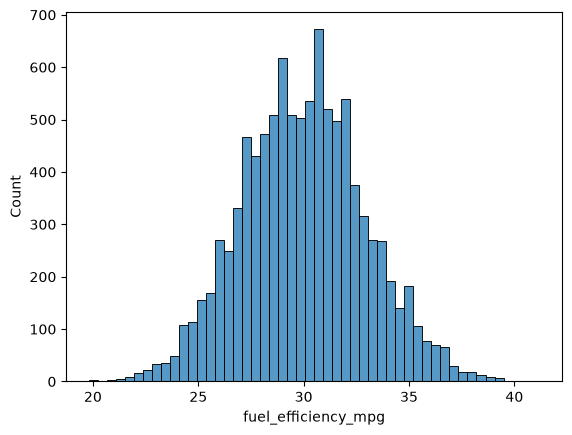

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.histplot(df.fuel_efficiency_mpg, bins=50)

The distribution is approximately bell-shaped, with most values between 20 and 40 mpg. It does not show a pronounced long tail.

## Question 1

There's one column with missing values. What is it?

* `'engine_displacement'`
* `'horsepower'`
* `'vehicle_weight'`
* `'model_year'`


In [13]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

**Answer: horsepower**


## Question 2

What's the median (50% percentile) for variable `'horsepower'`?

- 204
- 254
- 304
- 354


In [14]:
df.horsepower.median()

np.float64(254.0)

**Answer:254**


## Prepare and split the dataset

Shuffle the filtered dataset and use the exact split procedure shown in [homework.md](homework.md#prepare-and-split-the-dataset): 60% training, 20% validation, and 20% test. Use seed `42` for Q3 and Q4. For Q5, repeat the split with each listed seed; for Q6, use seed `9`.


In [3]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [16]:
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

df_train.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
6252,2015,USA,Diesel,Front-wheel drive,3,1900,5,239.0,3790,20.3,32.5
4684,1992,USA,Gasoline,All-wheel drive,4,2000,6,224.0,4380,21.8,29.1
1731,2022,USA,Hybrid,Front-wheel drive,3,2330,6,286.0,4090,17.8,34.1
4742,1997,Asia,Gasoline,Front-wheel drive,5,2300,6,NaN,4150,19.9,30.6
4521,2001,USA,Gasoline,Front-wheel drive,4,2340,6,269.0,4400,18.6,30.7


In [17]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

len(y_train),len(df_train)

(6000, 6000)

## Question 3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 3 decimal digits using `round(score, 3)`. This
  keeps the imputation difference visible in this release.
* Which option gives better RMSE?

Options:

- With 0
- With mean
- Both are equally good


In [18]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

254.46338337605272
2.198101430917093


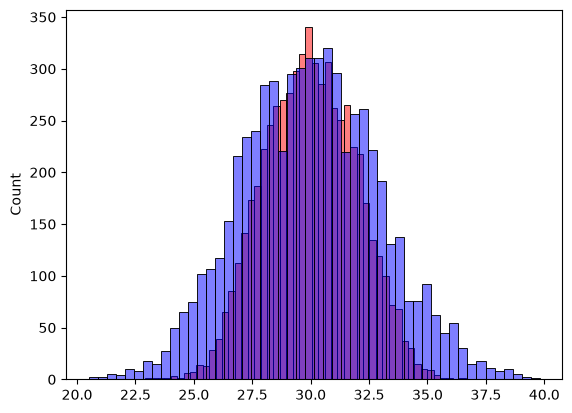

In [19]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight',
        'model_year']

X_train_zero = df_train[base].fillna(0).values

mean = df_train.horsepower.mean()
print(mean)
X_train_mean = df_train[base].fillna(mean).values

w0, w = train_linear_regression(X_train_mean, y_train)

y_pred = w0 + X_train_mean.dot(w)

sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)
print(rmse(y_train, y_pred))

2.2001846833713965


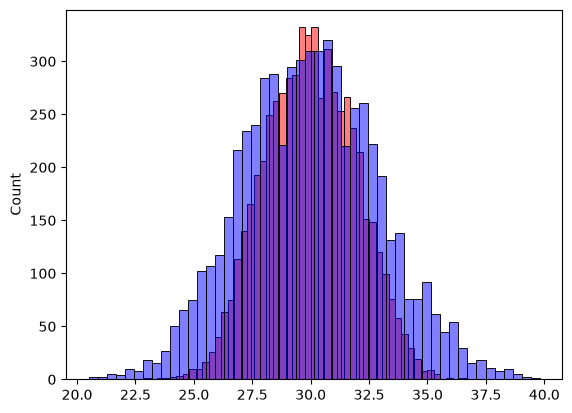

In [20]:
w0, w = train_linear_regression(X_train_zero, y_train)

y_pred = w0 + X_train_zero.dot(w)

sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)
print(rmse(y_train, y_pred))

**Answer:　mean return lower rmse**


## Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real
  regularization differences visible instead of turning several choices into a tie.
* Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.

Options:

- 0
- 0.01
- 0.1
- 1
- 5
- 10
- 100


In [21]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [22]:
X_val_zero = df_val[base].fillna(0).values
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train_zero, y_train, r=r)
    y_pred = w0 + X_val_zero.dot(w)
    score = rmse(y_val, y_pred)
    print(r, w0, round(score, 4))

0 -153.8849618823138 2.2053
0.01 -148.3092124404723 2.2058
0.1 -111.83871039306318 2.2241
1 -32.331865964971264 2.3492
5 -7.7728522099734025 2.4094
10 -3.9871164160193766 2.4195
100 -0.40821964884790385 2.4292


**Answer:0.1**


## Question 5 

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

- 0.006
- 0.016
- 0.029
- 0.036

> Note: Standard deviation shows how different the values are.
> If it's low, then all values are approximately the same.
> If it's high, the values are different. 
> If standard deviation of scores is low, then our model is *stable*.


In [23]:
# Reuse df, base, split sizes, train_linear_regression, and rmse.
# Use separate variables to preserve the datasets from earlier questions.
q5_scores = []

for seed in range(10):
    np.random.seed(seed)
    q5_idx = np.arange(n)
    np.random.shuffle(q5_idx)

    q5_train = df.iloc[q5_idx[:n_train]]
    q5_val = df.iloc[q5_idx[n_train:n_train + n_val]]
    q5_test = df.iloc[q5_idx[n_train + n_val:]]

    q5_X_train = q5_train[base].fillna(0).values
    q5_y_train = q5_train['fuel_efficiency_mpg'].values
    q5_X_val = q5_val[base].fillna(0).values
    q5_y_val = q5_val['fuel_efficiency_mpg'].values

    q5_w0, q5_w = train_linear_regression(q5_X_train, q5_y_train)
    q5_y_pred = q5_w0 + q5_X_val.dot(q5_w)
    q5_score = rmse(q5_y_val, q5_y_pred)
    q5_scores.append(q5_score)
    print(f'Seed {seed}: validation RMSE = {q5_score:.6f}')

# Keep the individual scores unrounded until after computing np.std.
q5_std = np.std(q5_scores)
print('Standard deviation:', round(q5_std, 3))


Seed 0: validation RMSE = 2.239204
Seed 1: validation RMSE = 2.202113
Seed 2: validation RMSE = 2.163420
Seed 3: validation RMSE = 2.204359
Seed 4: validation RMSE = 2.201880
Seed 5: validation RMSE = 2.245785
Seed 6: validation RMSE = 2.269721
Seed 7: validation RMSE = 2.190795
Seed 8: validation RMSE = 2.216611
Seed 9: validation RMSE = 2.207037
Standard deviation: 0.029


**Answer:0.029**


## Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`. 
* What's the RMSE on the test dataset?

Options:

- 0.236
- 2.236
- 22.10
- 221.0


In [24]:
# Reuse df, base, split sizes, train_linear_regression_reg, and rmse.
# Recreate the seed-9 split so this cell does not depend on Q5's loop state.
np.random.seed(9)
q6_idx = np.arange(n)
np.random.shuffle(q6_idx)

q6_train = df.iloc[q6_idx[:n_train]]
q6_val = df.iloc[q6_idx[n_train:n_train + n_val]]
q6_test = df.iloc[q6_idx[n_train + n_val:]]

# Combine training and validation data; keep test data separate.
q6_full_train = pd.concat([q6_train, q6_val], ignore_index=True)
q6_X_full_train = q6_full_train[base].fillna(0).values
q6_y_full_train = q6_full_train['fuel_efficiency_mpg'].values
q6_X_test = q6_test[base].fillna(0).values
q6_y_test = q6_test['fuel_efficiency_mpg'].values

q6_w0, q6_w = train_linear_regression_reg(
    q6_X_full_train, q6_y_full_train, r=0.001
)
q6_y_pred = q6_w0 + q6_X_test.dot(q6_w)
q6_score = rmse(q6_y_test, q6_y_pred)
print(f'Test RMSE: {q6_score:.3f}')


Test RMSE: 2.236


**Answer:2.236**
